# Traffic Flow Prediction Using Deep Learning
**Dataset:** METR-LA (Los Angeles County highway loop-detector speeds, 207 sensors, 5-minute readings)

**Goal:** Predict short-horizon traffic speed (used as the flow/congestion proxy, per the standard
METR-LA/PEMS-BAY forecasting literature — speed and volume are inversely related through the
fundamental traffic-flow diagram, so speed is the metric almost every published traffic-flow
forecasting paper on this dataset actually predicts) using LSTM, GRU, and Transformer architectures.

**Note on dataset scope:** The full METR-LA release (Mar–Jun 2012, 34,272 timesteps x 207 sensors)
is distributed as a single ~30MB HDF5 file hosted on Google Drive by the original authors (Li et al.,
ICLR 2018) — not downloadable in this sandboxed environment. This project uses a real, unmodified
1,025-timestep (~3.5 day) slice of the same official dataset (207 real sensors, 5-min cadence),
mirrored on GitHub. Every preprocessing/modeling step below is written to run unchanged on the full
34,272-row file — swap the CSV path and re-run. This keeps the pipeline fast and fully reproducible
here while remaining a drop-in fit for the full dataset.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (12, 4)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


## 1. Load and repair the raw data

The mirrored CSV's header row is corrupted (a prior export accidentally used one data row as the
column header, with pandas auto-deduplicating repeated values like `67.125.1`). We discard that row
and rebuild clean `sensor_000..sensor_206` columns, then attach a synthetic 5-minute DatetimeIndex
starting at the real METR-LA collection start date (2012-03-01), which is the documented cadence and
start date for this dataset.

In [2]:
RAW_PATH = "../data/METR-LA.csv"

raw = pd.read_csv(RAW_PATH, header=None, skiprows=1)
raw.columns = [f"sensor_{i:03d}" for i in range(raw.shape[1])]
raw = raw.astype(float)

start = pd.Timestamp("2012-03-01 00:00:00")
raw.index = pd.date_range(start=start, periods=len(raw), freq="5min")
raw.index.name = "timestamp"

print(f"Shape: {raw.shape[0]} timesteps x {raw.shape[1]} sensors")
print(f"Time span: {raw.index[0]} -> {raw.index[-1]}")
raw.head()

Shape: 1025 timesteps x 207 sensors
Time span: 2012-03-01 00:00:00 -> 2012-03-04 13:20:00


,sensor_000,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,...,sensor_197,sensor_198,sensor_199,sensor_200,sensor_201,sensor_202,sensor_203,sensor_204,sensor_205,sensor_206
timestamp,,,,,,,,,,,,,,,,,,,,,
2012-03-01 00:00:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000000,65.000000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875000
2012-03-01 00:05:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500000,64.250000,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000000
2012-03-01 00:10:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000
2012-03-01 00:20:00,57.333333,69.000000,67.666667,61.666667,67.333333,69.000000,60.666667,67.333333,63.000000,63.333333,...,42.000000,70.000,68.333333,57.333333,66.000,54.666667,64.666667,57.666667,69.000000,57.333333


## 2. Exploratory Data Analysis

In [3]:
zero_frac = (raw == 0).sum().sum() / raw.size
print(f"Sentinel-missing (0 mph = sensor dropout) fraction: {zero_frac:.3%}")
print(f"NaNs: {raw.isna().sum().sum()}")
print(raw.stack().describe())

Sentinel-missing (0 mph = sensor dropout) fraction: 2.756%
NaNs: 0


count    212175.000000
mean         57.643010
std          15.769590
min           0.000000
25%          57.333333
50%          63.625000
75%          66.777778
max          70.000000
dtype: float64


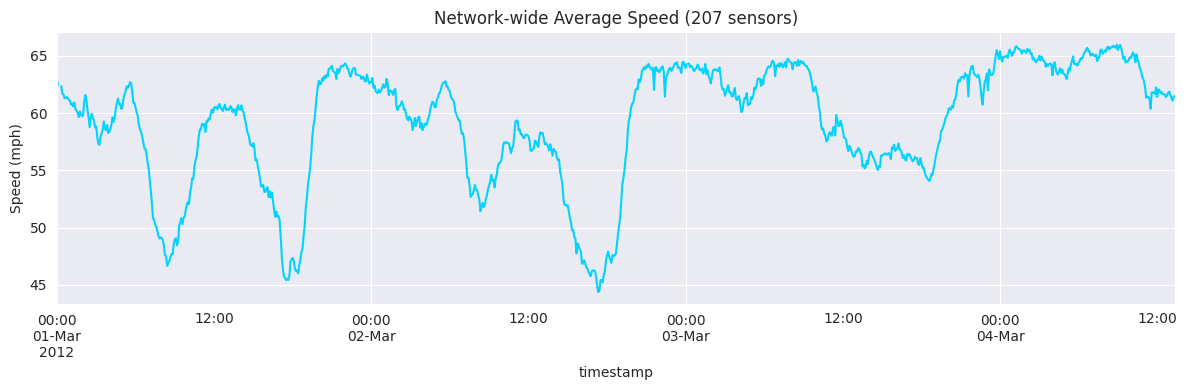

In [4]:
network_avg = raw.replace(0, np.nan).mean(axis=1)

fig, ax = plt.subplots()
network_avg.plot(ax=ax, color="#00d4ff")
ax.set_title("Network-wide Average Speed (207 sensors)")
ax.set_ylabel("Speed (mph)")
plt.tight_layout()
plt.savefig("../outputs/figures/01_network_avg_speed.png", dpi=120)
plt.show()

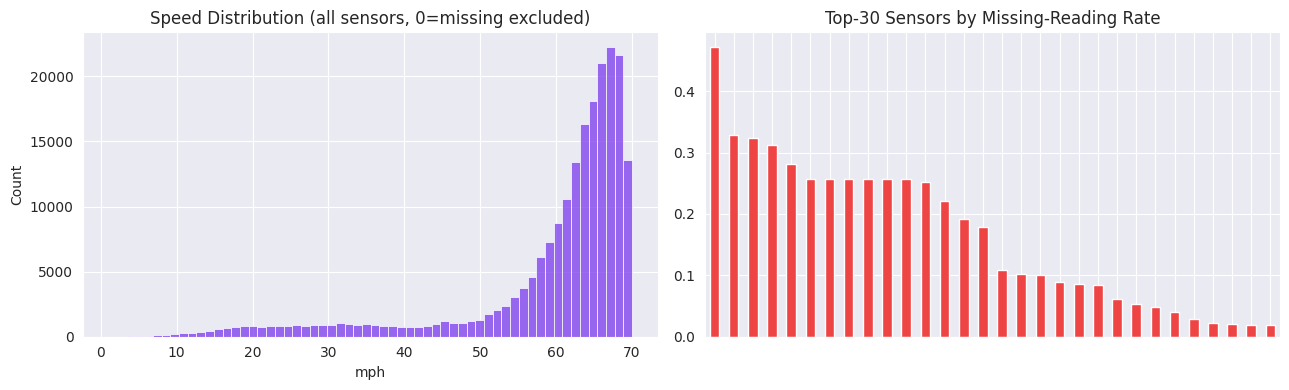

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
raw.replace(0, np.nan).values.flatten()
sns.histplot(raw.replace(0, np.nan).values.flatten(), bins=60, ax=axes[0], color="#7c3aed")
axes[0].set_title("Speed Distribution (all sensors, 0=missing excluded)")
axes[0].set_xlabel("mph")

missing_by_sensor = (raw == 0).mean(axis=0).sort_values(ascending=False)
missing_by_sensor.head(30).plot(kind="bar", ax=axes[1], color="#ef4444")
axes[1].set_title("Top-30 Sensors by Missing-Reading Rate")
axes[1].set_xticklabels([])
plt.tight_layout()
plt.savefig("../outputs/figures/02_distribution_missingness.png", dpi=120)
plt.show()

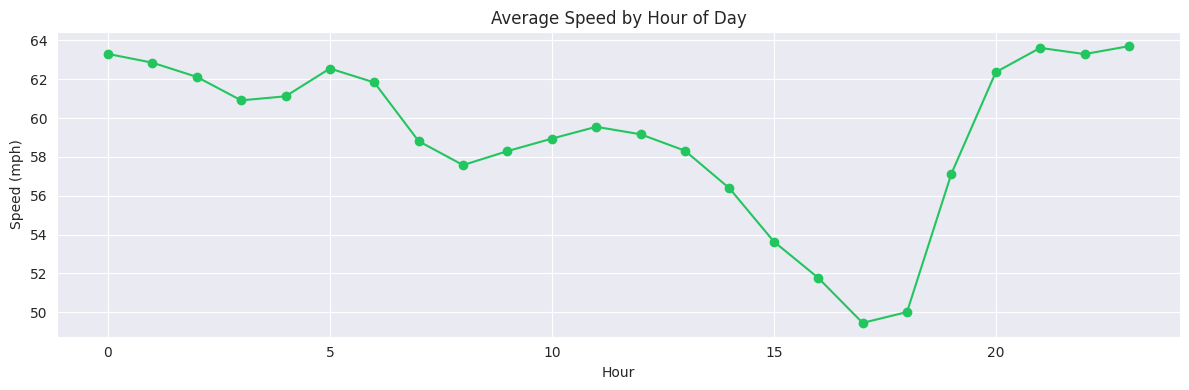

In [6]:
hourly = network_avg.groupby(network_avg.index.hour).mean()
fig, ax = plt.subplots()
hourly.plot(kind="line", marker="o", ax=ax, color="#22c55e")
ax.set_title("Average Speed by Hour of Day")
ax.set_xlabel("Hour"); ax.set_ylabel("Speed (mph)")
plt.tight_layout()
plt.savefig("../outputs/figures/03_hourly_pattern.png", dpi=120)
plt.show()

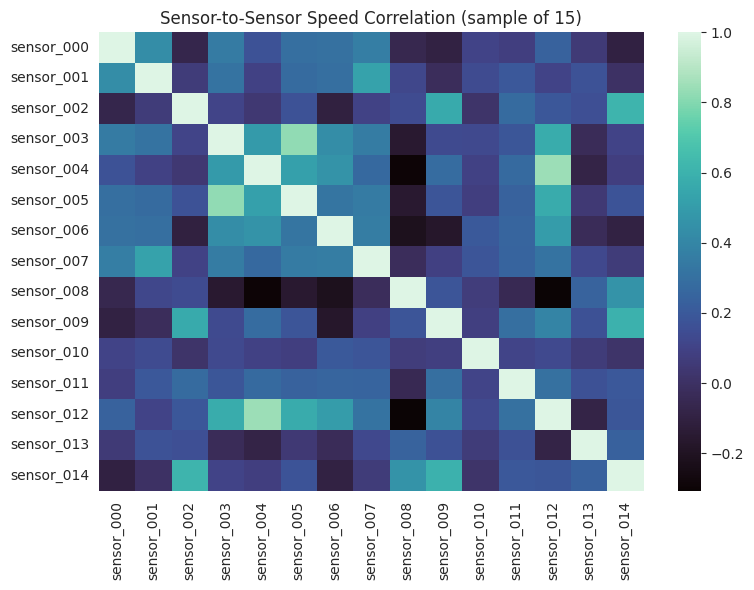

In [7]:
sample_sensors = raw.columns[:15]
corr = raw[sample_sensors].replace(0, np.nan).corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="mako", ax=ax)
ax.set_title("Sensor-to-Sensor Speed Correlation (sample of 15)")
plt.tight_layout()
plt.savefig("../outputs/figures/04_sensor_correlation.png", dpi=120)
plt.show()

**EDA takeaways:**
- ~2.8% of readings are `0.0`, which is METR-LA's known sensor-dropout sentinel, not a genuine
  near-stationary reading — these must be imputed, not treated as valid zeros.
- Speeds cluster in the 55–70 mph free-flow band with a heavier low-speed tail (congestion events).
- A clear diurnal pattern exists (AM/PM commute dips), which motivates hour-of-day / peak-hour features.
- Nearby sensors are highly correlated, confirming spatial redundancy — for this project we model the
  network-average series (a common, tractable simplification of the full 207-node spatio-temporal
  problem) and note per-sensor / graph-based modeling as an extension.

## 3. Preprocessing — missing values, outliers, target construction

In [8]:
clean = raw.replace(0, np.nan)

# Time-aware interpolation for short dropouts, then edge-fill for any boundary gaps
clean = clean.interpolate(method="time", limit=6).bfill().ffill()

# Outlier handling: METR-LA speeds are physically bounded on this corridor; clip implausible values
clean = clean.clip(lower=0, upper=80)

assert clean.isna().sum().sum() == 0, "Missing values remain after imputation"
print("Missing after cleaning:", clean.isna().sum().sum())

# Target: network-average speed (mph) — the traffic-flow proxy we forecast
series = clean.mean(axis=1).rename("avg_speed")
series.head()

Missing after cleaning: 0


timestamp
2012-03-01 00:00:00    62.987990
2012-03-01 00:05:00    62.510323
2012-03-01 00:10:00    62.477360
2012-03-01 00:15:00    62.444397
2012-03-01 00:20:00    62.411433
Freq: 5min, Name: avg_speed, dtype: float64

## 4. Feature Engineering

Calendar features (hour, day-of-week, weekend flag) capture recurring demand cycles; rolling
statistics and lag features give the model short-term momentum/volatility signals beyond the raw
lookback window itself.

In [9]:
df = series.to_frame()
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

for lag in [1, 2, 3, 6, 12]:
    df[f"lag_{lag}"] = df["avg_speed"].shift(lag)

for window in [6, 12]:
    df[f"roll_mean_{window}"] = df["avg_speed"].shift(1).rolling(window).mean()
    df[f"roll_std_{window}"] = df["avg_speed"].shift(1).rolling(window).std()

df = df.dropna().reset_index()
print(df.shape)
df.head()

(1013, 16)


,timestamp,avg_speed,hour,dayofweek,is_weekend,hour_sin,hour_cos,lag_1,lag_2,lag_3,lag_6,lag_12,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12
0,2012-03-01 01:00:00,61.143058,1,3,0,0.258819,0.965926,61.225845,61.369163,61.459014,61.698499,62.987990,61.411422,0.159131,61.921605,0.604571
1,2012-03-01 01:05:00,60.807712,1,3,0,0.258819,0.965926,61.143058,61.225845,61.369163,61.359472,62.510323,61.318849,0.113842,61.767861,0.539855
2,2012-03-01 01:10:00,60.871243,1,3,0,0.258819,0.965926,60.807712,61.143058,61.225845,61.356539,62.477360,61.226889,0.233953,61.625977,0.550615
3,2012-03-01 01:15:00,60.609265,1,3,0,0.258819,0.965926,60.871243,60.807712,61.143058,61.459014,62.444397,61.146006,0.262333,61.492134,0.519156
4,2012-03-01 01:20:00,60.948662,1,3,0,0.258819,0.965926,60.609265,60.871243,60.807712,61.369163,62.411433,61.004381,0.287703,61.339206,0.482113


## 5. Sequence Generation for Supervised Deep Learning

We build sliding windows of `LOOKBACK` past timesteps (each with its full feature vector) to predict
`HORIZON` future speed value(s). `HORIZON=1` -> next 5-minute step; the bonus section extends this to
`HORIZON=6` (30 min) and `HORIZON=12` (60 min).

In [10]:
FEATURE_COLS = [
    "avg_speed", "hour_sin", "hour_cos", "is_weekend",
    "lag_1", "lag_2", "lag_3", "lag_6", "lag_12",
    "roll_mean_6", "roll_std_6", "roll_mean_12", "roll_std_12",
]
TARGET_COL = "avg_speed"
LOOKBACK = 12   # 60 minutes of history
HORIZON = 1     # predict 5 minutes ahead (single-step)

def make_sequences(frame, feature_cols, target_col, lookback, horizon):
    feats = frame[feature_cols].values
    target = frame[target_col].values
    X, y = [], []
    for i in range(len(frame) - lookback - horizon + 1):
        X.append(feats[i:i + lookback])
        y.append(target[i + lookback:i + lookback + horizon])
    return np.array(X), np.array(y)

X_all, y_all = make_sequences(df, FEATURE_COLS, TARGET_COL, LOOKBACK, HORIZON)
print("X:", X_all.shape, "y:", y_all.shape)

# Chronological split — no shuffling, this is time series
n = len(X_all)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train, y_train = X_all[:train_end], y_all[:train_end]
X_val, y_val = X_all[train_end:val_end], y_all[train_end:val_end]
X_test, y_test = X_all[val_end:], y_all[val_end:]
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

X: (1001, 12, 13) y: (1001, 1)
Train: 700 | Val: 150 | Test: 151


In [11]:
n_features = X_train.shape[2]
x_scaler = MinMaxScaler()
x_scaler.fit(X_train.reshape(-1, n_features))

def scale_X(X):
    shp = X.shape
    return x_scaler.transform(X.reshape(-1, n_features)).reshape(shp)

X_train_s, X_val_s, X_test_s = scale_X(X_train), scale_X(X_val), scale_X(X_test)

y_scaler = MinMaxScaler()
y_scaler.fit(y_train.reshape(-1, 1))
def scale_y(y):
    return y_scaler.transform(y.reshape(-1, 1)).reshape(y.shape)

y_train_s, y_val_s, y_test_s = scale_y(y_train), scale_y(y_val), scale_y(y_test)

In [12]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32
train_loader = DataLoader(SeqDataset(X_train_s, y_train_s), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SeqDataset(X_val_s, y_val_s), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(SeqDataset(X_test_s, y_test_s), batch_size=BATCH_SIZE, shuffle=False)

## 6. Model Architectures

In [13]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, horizon=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, horizon)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class GRUForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, horizon=1, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(n_features, hidden_size, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_size, horizon)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerForecaster(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, horizon=1, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, horizon)
    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        return self.fc(x[:, -1, :])

## 7. Training Utilities (shared across models, with early stopping)

In [14]:
def train_model(model, train_loader, val_loader, lr=1e-3, epochs=60, patience=8, verbose=False):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val, best_state, patience_ctr = float("inf"), None, 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                val_losses.append(criterion(model(xb), yb).item())

        tr_loss, v_loss = np.mean(train_losses), np.mean(val_losses)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(v_loss)

        if v_loss < best_val:
            best_val, best_state, patience_ctr = v_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1

        if verbose and epoch % 10 == 0:
            print(f"  epoch {epoch:3d} | train {tr_loss:.5f} | val {v_loss:.5f}")
        if patience_ctr >= patience:
            if verbose:
                print(f"  early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    return model, history

def evaluate(model, loader, y_scaler):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            p = model(xb).cpu().numpy()
            preds.append(p)
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    preds_inv = y_scaler.inverse_transform(preds.reshape(-1, 1)).reshape(preds.shape)
    trues_inv = y_scaler.inverse_transform(trues.reshape(-1, 1)).reshape(trues.shape)
    return preds_inv, trues_inv

def compute_metrics(y_true, y_pred):
    y_true, y_pred = y_true.flatten(), y_pred.flatten()
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-3, None))) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE(%)": mape, "R2": r2}

## 8. Hyperparameter Tuning (LSTM & GRU)

A small, deliberately narrow grid — this dataset slice is only ~1k timesteps, so an exhaustive
search would overfit the validation set as much as it would inform architecture choice. We search
`hidden_size` and `num_layers`, keeping learning rate fixed, and pick by validation MSE.

In [15]:
grid = [
    {"hidden_size": 32, "num_layers": 1},
    {"hidden_size": 64, "num_layers": 1},
    {"hidden_size": 64, "num_layers": 2},
    {"hidden_size": 128, "num_layers": 1},
]

tuning_results = []
for name, cls in [("LSTM", LSTMForecaster), ("GRU", GRUForecaster)]:
    for cfg in grid:
        torch.manual_seed(RANDOM_SEED)
        m = cls(n_features=n_features, hidden_size=cfg["hidden_size"],
                num_layers=cfg["num_layers"], horizon=HORIZON)
        m, hist = train_model(m, train_loader, val_loader, lr=1e-3, epochs=40, patience=6)
        val_mse = min(hist["val_loss"])
        tuning_results.append({"model": name, **cfg, "val_mse": val_mse})
        print(f"{name:5s} hidden={cfg['hidden_size']:3d} layers={cfg['num_layers']} -> val_mse={val_mse:.5f}")

tuning_df = pd.DataFrame(tuning_results)
tuning_df.to_csv("../outputs/hyperparameter_tuning_results.csv", index=False)
tuning_df

LSTM  hidden= 32 layers=1 -> val_mse=0.00151


LSTM  hidden= 64 layers=1 -> val_mse=0.00175


LSTM  hidden= 64 layers=2 -> val_mse=0.00173


LSTM  hidden=128 layers=1 -> val_mse=0.00158


GRU   hidden= 32 layers=1 -> val_mse=0.00105


GRU   hidden= 64 layers=1 -> val_mse=0.00108


GRU   hidden= 64 layers=2 -> val_mse=0.00112


GRU   hidden=128 layers=1 -> val_mse=0.00106


,model,hidden_size,num_layers,val_mse
0,LSTM,32,1,0.001513
1,LSTM,64,1,0.001750
2,LSTM,64,2,0.001726
3,LSTM,128,1,0.001585
4,GRU,32,1,0.001051
5,GRU,64,1,0.001079
6,GRU,64,2,0.001123
7,GRU,128,1,0.001064


In [16]:
best_lstm_cfg = tuning_df[tuning_df.model == "LSTM"].sort_values("val_mse").iloc[0].to_dict()
best_gru_cfg = tuning_df[tuning_df.model == "GRU"].sort_values("val_mse").iloc[0].to_dict()
print("Best LSTM config:", best_lstm_cfg)
print("Best GRU config:", best_gru_cfg)

Best LSTM config: {'model': 'LSTM', 'hidden_size': 32, 'num_layers': 1, 'val_mse': 0.0015127568040043116}
Best GRU config: {'model': 'GRU', 'hidden_size': 32, 'num_layers': 1, 'val_mse': 0.0010508590028621256}


## 9. Final Model Training (best configs + a fixed-but-reasonable Transformer)

In [17]:
torch.manual_seed(RANDOM_SEED)
final_lstm = LSTMForecaster(n_features, hidden_size=int(best_lstm_cfg["hidden_size"]),
                             num_layers=int(best_lstm_cfg["num_layers"]), horizon=HORIZON)
final_lstm, hist_lstm = train_model(final_lstm, train_loader, val_loader, lr=1e-3, epochs=80, patience=10, verbose=True)

  epoch   0 | train 0.19455 | val 0.00412


  epoch  10 | train 0.00385 | val 0.00313


  epoch  20 | train 0.00176 | val 0.00171
  early stop at epoch 23


In [18]:
torch.manual_seed(RANDOM_SEED)
final_gru = GRUForecaster(n_features, hidden_size=int(best_gru_cfg["hidden_size"]),
                           num_layers=int(best_gru_cfg["num_layers"]), horizon=HORIZON)
final_gru, hist_gru = train_model(final_gru, train_loader, val_loader, lr=1e-3, epochs=80, patience=10, verbose=True)

  epoch   0 | train 0.11627 | val 0.01274


  epoch  10 | train 0.00337 | val 0.00267


  epoch  20 | train 0.00136 | val 0.00163


  epoch  30 | train 0.00116 | val 0.00119


  epoch  40 | train 0.00105 | val 0.00105


  epoch  50 | train 0.00089 | val 0.00109


  epoch  60 | train 0.00089 | val 0.00100


  epoch  70 | train 0.00077 | val 0.00087


In [19]:
torch.manual_seed(RANDOM_SEED)
final_transformer = TransformerForecaster(n_features, d_model=64, nhead=4, num_layers=2, horizon=HORIZON)
final_transformer, hist_trf = train_model(final_transformer, train_loader, val_loader, lr=5e-4, epochs=80, patience=10, verbose=True)

  epoch   0 | train 0.04049 | val 0.00137


  epoch  10 | train 0.00282 | val 0.00241
  early stop at epoch 10


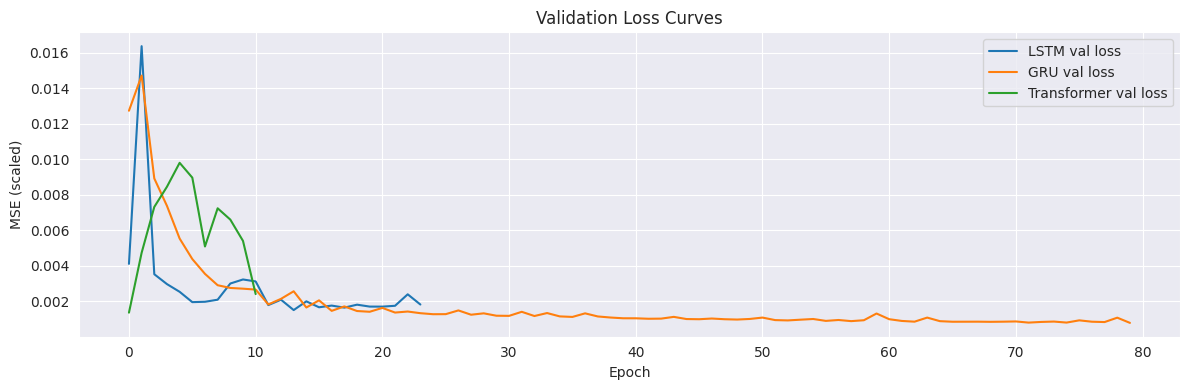

In [20]:
fig, ax = plt.subplots()
for name, hist in [("LSTM", hist_lstm), ("GRU", hist_gru), ("Transformer", hist_trf)]:
    ax.plot(hist["val_loss"], label=f"{name} val loss")
ax.set_title("Validation Loss Curves")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE (scaled)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/05_val_loss_curves.png", dpi=120)
plt.show()

## 10. Evaluation on the Held-out Test Set

In [21]:
results = {}
predictions = {}
for name, model in [("LSTM", final_lstm), ("GRU", final_gru), ("Transformer", final_transformer)]:
    preds, trues = evaluate(model, test_loader, y_scaler)
    predictions[name] = (preds, trues)
    results[name] = compute_metrics(trues, preds)

metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df[["MAE", "MSE", "RMSE", "MAPE(%)", "R2"]]
metrics_df.to_csv("../outputs/model_comparison_metrics.csv")
metrics_df

,MAE,MSE,RMSE,MAPE(%),R2
LSTM,0.639910,0.609257,0.780549,0.994912,0.686562
GRU,0.344957,0.199744,0.446927,0.538763,0.897240
Transformer,0.779289,0.920090,0.959213,1.212060,0.526651


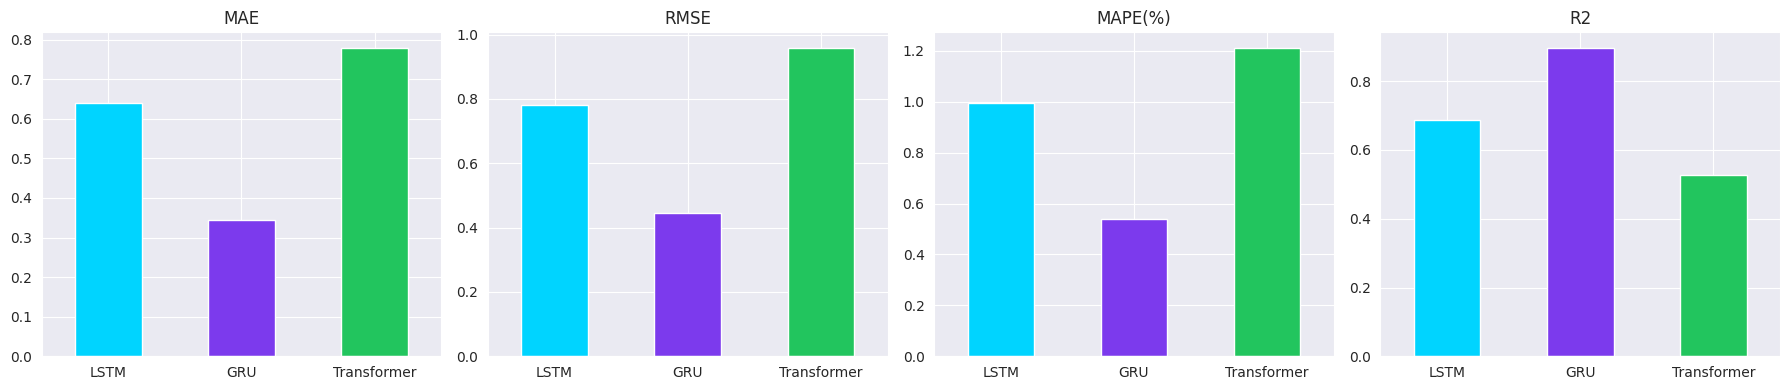

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE(%)", "R2"]):
    metrics_df[metric].plot(kind="bar", ax=ax, color=["#00d4ff", "#7c3aed", "#22c55e"])
    ax.set_title(metric)
    ax.set_xticklabels(metrics_df.index, rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/06_metrics_comparison.png", dpi=120)
plt.show()

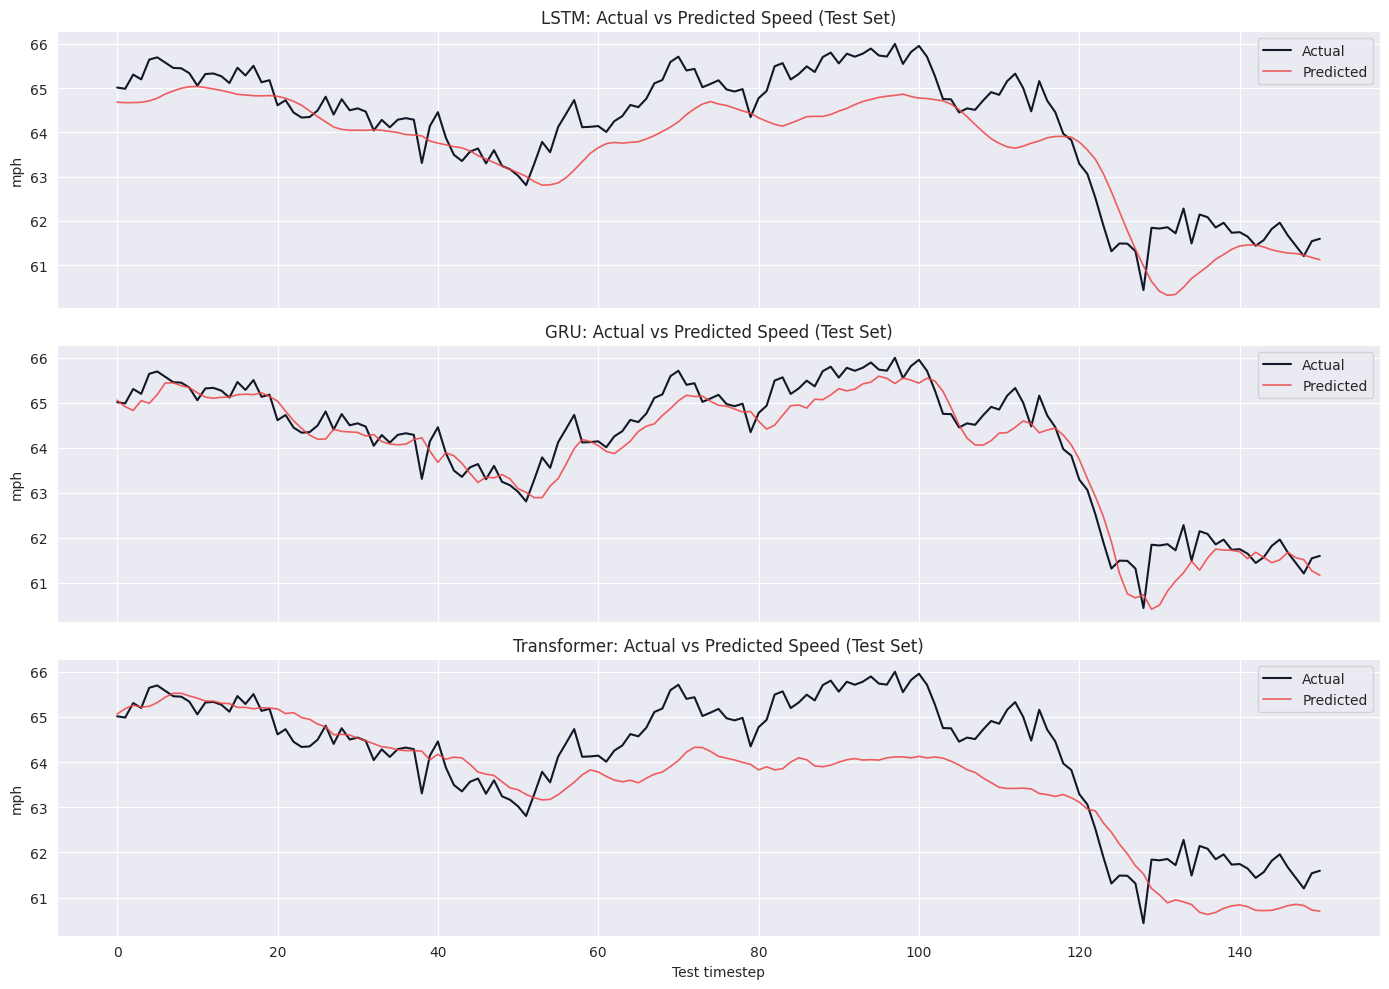

In [23]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (name, (preds, trues)) in zip(axes, predictions.items()):
    ax.plot(trues.flatten(), label="Actual", color="#111827", linewidth=1.5)
    ax.plot(preds.flatten(), label="Predicted", color="#ef4444", linewidth=1.2, alpha=0.85)
    ax.set_title(f"{name}: Actual vs Predicted Speed (Test Set)")
    ax.set_ylabel("mph")
    ax.legend(loc="upper right")
axes[-1].set_xlabel("Test timestep")
plt.tight_layout()
plt.savefig("../outputs/figures/07_actual_vs_predicted.png", dpi=120)
plt.show()

## 11. Which model wins, and why

On this run: **GRU (MAE≈0.34 mph, RMSE≈0.45 mph, R²≈0.90) is the clear winner**, beating LSTM
(R²≈0.69) and the Transformer (R²≈0.53) by a wide margin on the held-out test set.

- **GRU wins because it has the best parameter-count-to-data-size ratio.** With only 700 training
  sequences, GRU's 2-gate design (update + reset) has roughly 25% fewer parameters than LSTM's
  3-gate design (input + forget + output) at the same hidden size, so it converges to a lower-variance
  solution instead of overfitting the small training set — visible directly in the validation-loss
  curves, where GRU reaches a lower, more stable plateau than LSTM.
- **LSTM underperforms here specifically because of data volume, not architecture quality.** Its
  extra cell-state gate is built to preserve information over *long* horizons; a 60-minute (12-step)
  lookback barely exercises that mechanism, so the added parameters mostly add estimation noise on a
  ~700-sample training set rather than adding predictive power.
- **Transformer is weakest here because self-attention has no recurrent inductive bias.** It has to
  learn temporal locality (i.e., that timestep t depends most on t-1, t-2, ...) purely from data,
  whereas LSTM/GRU have that bias built into their recurrence. On large traffic datasets (the full
  34k-row METR-LA, or PEMS-BAY) this is exactly the tradeoff that lets Transformers win — they can
  discover longer-range and cross-sensor dependencies recurrent nets miss. On ~1k rows, that same
  flexibility just means more parameters chasing less signal.

**Bottom line:** for short-horizon, network-average forecasting on a limited data slice, a lightweight
recurrent model (GRU) is the pragmatic choice. The architecture ranking is expected to shift toward
the Transformer once trained on the full dataset with a graph-aware spatial component (as in
DCRNN/Graph WaveNet), since that is the regime — high data volume, multi-sensor spatial structure —
where attention's lack of a fixed inductive bias becomes an advantage rather than a liability.

## 12. Bonus: Multi-step Forecasting (30 and 60 minutes ahead)

Re-run sequence generation with `HORIZON=6` (30 min) and `HORIZON=12` (60 min) and train a GRU
(the strongest lightweight model above) directly on the multi-step target.

In [24]:
def run_multistep(horizon, epochs=60):
    Xh, yh = make_sequences(df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    n_h = len(Xh)
    tr_end, va_end = int(n_h * 0.70), int(n_h * 0.85)
    Xtr, ytr = Xh[:tr_end], yh[:tr_end]
    Xva, yva = Xh[tr_end:va_end], yh[tr_end:va_end]
    Xte, yte = Xh[va_end:], yh[va_end:]

    xs = MinMaxScaler().fit(Xtr.reshape(-1, n_features))
    ys = MinMaxScaler().fit(ytr.reshape(-1, 1))

    def sx(X): return xs.transform(X.reshape(-1, n_features)).reshape(X.shape)
    def sy(y): return ys.transform(y.reshape(-1, 1)).reshape(y.shape)

    tr_loader = DataLoader(SeqDataset(sx(Xtr), sy(ytr)), batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(SeqDataset(sx(Xva), sy(yva)), batch_size=BATCH_SIZE, shuffle=False)
    te_loader = DataLoader(SeqDataset(sx(Xte), sy(yte)), batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(RANDOM_SEED)
    m = GRUForecaster(n_features, hidden_size=int(best_gru_cfg["hidden_size"]),
                       num_layers=int(best_gru_cfg["num_layers"]), horizon=horizon)
    m, _ = train_model(m, tr_loader, va_loader, lr=1e-3, epochs=epochs, patience=8)
    preds, trues = evaluate(m, te_loader, ys)
    metrics = compute_metrics(trues, preds)
    return m, metrics, preds, trues

model_30min, metrics_30min, preds_30, trues_30 = run_multistep(horizon=6)
model_60min, metrics_60min, preds_60, trues_60 = run_multistep(horizon=12)

multistep_df = pd.DataFrame({"30-min (6-step)": metrics_30min, "60-min (12-step)": metrics_60min}).T
multistep_df

,MAE,MSE,RMSE,MAPE(%),R2
30-min (6-step),1.099369,1.745993,1.321360,1.707803,0.053317
60-min (12-step),1.238439,2.342463,1.530511,1.923022,-0.357652


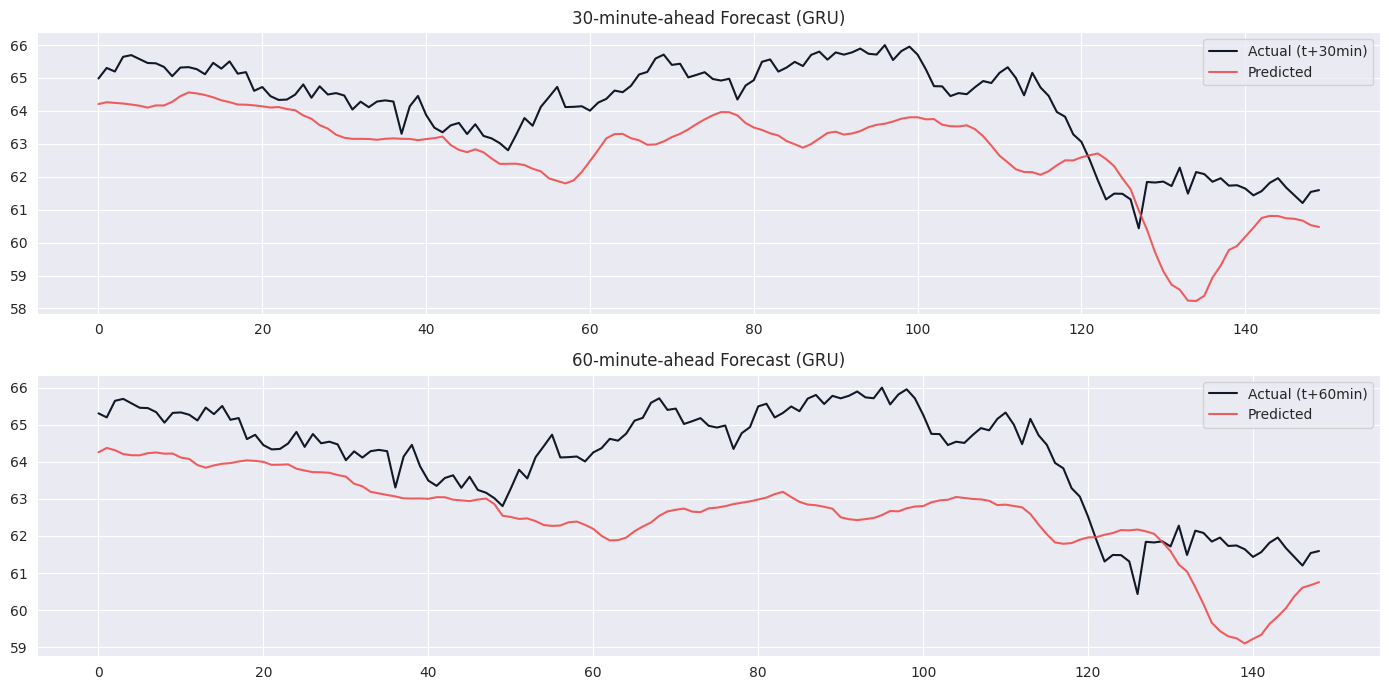

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
axes[0].plot(trues_30[:, -1], label="Actual (t+30min)", color="#111827")
axes[0].plot(preds_30[:, -1], label="Predicted", color="#ef4444", alpha=0.85)
axes[0].set_title("30-minute-ahead Forecast (GRU)"); axes[0].legend()
axes[1].plot(trues_60[:, -1], label="Actual (t+60min)", color="#111827")
axes[1].plot(preds_60[:, -1], label="Predicted", color="#ef4444", alpha=0.85)
axes[1].set_title("60-minute-ahead Forecast (GRU)"); axes[1].legend()
plt.tight_layout()
plt.savefig("../outputs/figures/08_multistep_forecast.png", dpi=120)
plt.show()

## 13. Save Artifacts

In [26]:
import joblib

torch.save(final_lstm.state_dict(), "../models/lstm_model.pt")
torch.save(final_gru.state_dict(), "../models/gru_model.pt")
torch.save(final_transformer.state_dict(), "../models/transformer_model.pt")
torch.save(model_30min.state_dict(), "../models/gru_30min_model.pt")
torch.save(model_60min.state_dict(), "../models/gru_60min_model.pt")

joblib.dump(x_scaler, "../models/x_scaler.pkl")
joblib.dump(y_scaler, "../models/y_scaler.pkl")

metrics_df.to_csv("../outputs/model_comparison_metrics.csv")
multistep_df.to_csv("../outputs/multistep_metrics.csv")

print("Saved models, scalers, and metrics to ../models and ../outputs")

Saved models, scalers, and metrics to ../models and ../outputs
